# Customer Conversion Analysis

This notebook analyses customer conversion across two different marketing contexts using the UCI Bank Marketing and Online Shoppers Purchasing Intention datasets.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)

## 1. Data Loading

In [2]:
DATA_DIR = Path(".")

BANK_FILE = DATA_DIR / "bank-additional-full.csv"
SHOP_FILE = DATA_DIR / "online_shoppers_intention.csv"

print("Bank dataset exists:", BANK_FILE.exists())
print("Online Shoppers dataset exists:", SHOP_FILE.exists())

Bank dataset exists: True
Online Shoppers dataset exists: True


In [3]:
bank = pd.read_csv(BANK_FILE, sep=";")
shop = pd.read_csv(SHOP_FILE)

print("Datasets loaded successfully.")

Datasets loaded successfully.


## 2. Initial Data Inspection

In [4]:
print("Bank Marketing shape:", bank.shape)
print("Online Shoppers shape:", shop.shape)

Bank Marketing shape: (41188, 21)
Online Shoppers shape: (12330, 18)


In [5]:
print("Bank Marketing - First 5 rows")
display(bank.head())

print("\nOnline Shoppers - First 5 rows")
display(shop.head())

Bank Marketing - First 5 rows


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



Online Shoppers - First 5 rows


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
print("Bank Marketing columns:")
print(bank.columns.tolist())

print("\nOnline Shoppers columns:")
print(shop.columns.tolist())

Bank Marketing columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Online Shoppers columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [7]:
print("BANK MARKETING DATA TYPES")
bank.info()

print("\n" + "=" * 60 + "\n")

print("ONLINE SHOPPERS DATA TYPES")
shop.info()

BANK MARKETING DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.

## 3. Exploratory Data Checks

In [8]:
print("Bank Marketing - Numerical Summary")
display(bank.describe().T)

print("\nOnline Shoppers - Numerical Summary")
display(shop.describe().T)

Bank Marketing - Numerical Summary


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100



Online Shoppers - Numerical Summary


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [9]:
print("BANK MARKETING TARGET")
print(bank["y"].value_counts())

print("\nBank Marketing target percentages:")
print((bank["y"].value_counts(normalize=True) * 100).round(2))

print("\n" + "=" * 60 + "\n")

print("ONLINE SHOPPERS TARGET")
print(shop["Revenue"].value_counts())

print("\nOnline Shoppers target percentages:")
print((shop["Revenue"].value_counts(normalize=True) * 100).round(2))

BANK MARKETING TARGET
y
no     36548
yes     4640
Name: count, dtype: int64

Bank Marketing target percentages:
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


ONLINE SHOPPERS TARGET
Revenue
False    10422
True      1908
Name: count, dtype: int64

Online Shoppers target percentages:
Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64


In [10]:
print("BANK MARKETING MISSING VALUES")
bank_missing = bank.isnull().sum()
print(bank_missing[bank_missing > 0])
print("Total missing values:", bank.isnull().sum().sum())

print("\n" + "=" * 60 + "\n")

print("ONLINE SHOPPERS MISSING VALUES")
shop_missing = shop.isnull().sum()
print(shop_missing[shop_missing > 0])
print("Total missing values:", shop.isnull().sum().sum())

BANK MARKETING MISSING VALUES
Series([], dtype: int64)
Total missing values: 0


ONLINE SHOPPERS MISSING VALUES
Series([], dtype: int64)
Total missing values: 0


In [11]:
print("Bank Marketing duplicate rows:", bank.duplicated().sum())
print("Online Shoppers duplicate rows:", shop.duplicated().sum())

Bank Marketing duplicate rows: 12
Online Shoppers duplicate rows: 125


### Unknown categorical values

Although the Bank Marketing dataset contains no conventional null values, some categorical attributes use the value unknown. These values are examined separately before preprocessing.

In [12]:
categorical_columns = bank.select_dtypes(include="object").columns

unknown_counts = []

for column in categorical_columns:
    if column != "y":
        count = (bank[column] == "unknown").sum()
        percentage = (count / len(bank)) * 100

        unknown_counts.append({
            "Variable": column,
            "Unknown_Count": count,
            "Unknown_Percentage": round(percentage, 2)
        })

unknown_table = pd.DataFrame(unknown_counts)
unknown_table = unknown_table.sort_values(
    by="Unknown_Count",
    ascending=False
)

display(unknown_table)

,Variable,Unknown_Count,Unknown_Percentage
3,default,8597,20.87
2,education,1731,4.20
4,housing,990,2.40
5,loan,990,2.40
0,job,330,0.80
1,marital,80,0.19
6,contact,0,0.00
7,month,0,0.00
8,day_of_week,0,0.00
9,poutcome,0,0.00


In [13]:
print("BANK MARKETING CATEGORICAL VARIABLES")

for column in bank.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(bank[column].value_counts())

BANK MARKETING CATEGORICAL VARIABLES

job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing:
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan:
loan
no         33950
yes         6248
unknown      990
Na

In [14]:
print("ONLINE SHOPPERS CATEGORICAL VARIABLES")

categorical_shop = ["Month", "VisitorType"]

for column in categorical_shop:
    print(f"\n{column}:")
    print(shop[column].value_counts())

ONLINE SHOPPERS CATEGORICAL VARIABLES

Month:
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

VisitorType:
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64


In [15]:
target_summary = pd.DataFrame({
    "Dataset": ["Bank Marketing", "Online Shoppers"],
    "Total_Records": [len(bank), len(shop)],
    "Conversions": [
        (bank["y"] == "yes").sum(),
        (shop["Revenue"] == True).sum()
    ]
})

target_summary["Conversion_Rate_Percent"] = (
    target_summary["Conversions"]
    / target_summary["Total_Records"]
    * 100
).round(2)

display(target_summary)

,Dataset,Total_Records,Conversions,Conversion_Rate_Percent
0,Bank Marketing,41188,4640,11.27
1,Online Shoppers,12330,1908,15.47


In [16]:
print("DUPLICATE ROWS")
print("Bank Marketing:", bank.duplicated().sum())
print("Online Shoppers:", shop.duplicated().sum())

print("\nONLINE SHOPPERS TARGET")
print(shop["Revenue"].value_counts())

print("\nPercentages:")
print((shop["Revenue"].value_counts(normalize=True) * 100).round(2))

DUPLICATE ROWS
Bank Marketing: 12
Online Shoppers: 125

ONLINE SHOPPERS TARGET
Revenue
False    10422
True      1908
Name: count, dtype: int64

Percentages:
Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64


## 4. Data Cleaning and Preparation

In [17]:

bank_clean = bank.copy()
shop_clean = shop.copy()

# Remove exact duplicate rows
bank_clean = bank_clean.drop_duplicates().reset_index(drop=True)
shop_clean = shop_clean.drop_duplicates().reset_index(drop=True)

print("Bank Marketing after duplicate removal:", bank_clean.shape)
print("Online Shoppers after duplicate removal:", shop_clean.shape)

Bank Marketing after duplicate removal: (41176, 21)
Online Shoppers after duplicate removal: (12205, 18)


### Treatment of unknown values

The Bank Marketing dataset contains no conventional missing values, but some categorical variables use the label unknown. These values are retained as a separate category because replacing them would require assumptions that are not supported by the original data.

### Exclusion of call duration

The duration variable is excluded from the main Bank Marketing model because call duration is only known after the marketing call has occurred. Since the aim is to support customer targeting before contact, using this variable would include information that is unavailable at the time of prediction.

In [18]:
bank_clean = bank_clean.drop(columns=["duration"])

print("Bank Marketing shape after removing duration:", bank_clean.shape)

Bank Marketing shape after removing duration: (41176, 20)


In [19]:
# Bank Marketing
X_bank = bank_clean.drop(columns=["y"])
y_bank = bank_clean["y"].map({"no": 0, "yes": 1})

# Online Shoppers
X_shop = shop_clean.drop(columns=["Revenue"])
y_shop = shop_clean["Revenue"].astype(int)

print("Bank predictors:", X_bank.shape)
print("Bank target:", y_bank.shape)

print("\nOnline Shoppers predictors:", X_shop.shape)
print("Online Shoppers target:", y_shop.shape)

Bank predictors: (41176, 19)
Bank target: (41176,)

Online Shoppers predictors: (12205, 17)
Online Shoppers target: (12205,)


## 5. Preprocessing and Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Bank Marketing


bank_categorical = X_bank.select_dtypes(include="object").columns.tolist()
bank_numerical = X_bank.select_dtypes(exclude="object").columns.tolist()

print("Bank categorical variables:", bank_categorical)
print("Bank numerical variables:", bank_numerical)

Bank categorical variables: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Bank numerical variables: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [21]:

# Online Shoppers


shop_categorical = [
    "Month",
    "VisitorType",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "Weekend"
]

shop_numerical = [
    col for col in X_shop.columns
    if col not in shop_categorical
]

print("Online Shoppers categorical variables:", shop_categorical)
print("Online Shoppers numerical variables:", shop_numerical)

Online Shoppers categorical variables: ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']
Online Shoppers numerical variables: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


In [22]:
X_bank_train, X_bank_test, y_bank_train, y_bank_test = train_test_split(
    X_bank,
    y_bank,
    test_size=0.20,
    random_state=42,
    stratify=y_bank
)

X_shop_train, X_shop_test, y_shop_train, y_shop_test = train_test_split(
    X_shop,
    y_shop,
    test_size=0.20,
    random_state=42,
    stratify=y_shop
)

print("Bank training set:", X_bank_train.shape)
print("Bank test set:", X_bank_test.shape)

print("\nOnline Shoppers training set:", X_shop_train.shape)
print("Online Shoppers test set:", X_shop_test.shape)

Bank training set: (32940, 19)
Bank test set: (8236, 19)

Online Shoppers training set: (9764, 17)
Online Shoppers test set: (2441, 17)


In [23]:
bank_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), bank_numerical),
        ("cat", OneHotEncoder(handle_unknown="ignore"), bank_categorical)
    ]
)

shop_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), shop_numerical),
        ("cat", OneHotEncoder(handle_unknown="ignore"), shop_categorical)
    ]
)

## 6. Model 1: Logistic Regression

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Bank Marketing Logistic Regression pipeline
bank_lr = Pipeline([
    ("preprocessor", bank_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Online Shoppers Logistic Regression pipeline
shop_lr = Pipeline([
    ("preprocessor", shop_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [25]:
bank_lr.fit(X_bank_train, y_bank_train)
shop_lr.fit(X_shop_train, y_shop_train)

print("Logistic Regression models trained successfully.")

Logistic Regression models trained successfully.


In [26]:
# Predicted classes
bank_lr_pred = bank_lr.predict(X_bank_test)
shop_lr_pred = shop_lr.predict(X_shop_test)

# Predicted probabilities for the positive class
bank_lr_prob = bank_lr.predict_proba(X_bank_test)[:, 1]
shop_lr_prob = shop_lr.predict_proba(X_shop_test)[:, 1]

print("Predictions completed.")

Predictions completed.


### Logistic Regression Evaluation

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [28]:
def evaluate_model(y_true, y_pred, y_prob, dataset_name):
    results = {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

    return results

In [29]:
bank_lr_results = evaluate_model(
    y_bank_test,
    bank_lr_pred,
    bank_lr_prob,
    "Bank Marketing"
)

shop_lr_results = evaluate_model(
    y_shop_test,
    shop_lr_pred,
    shop_lr_prob,
    "Online Shoppers"
)

lr_results = pd.DataFrame([
    bank_lr_results,
    shop_lr_results
])

display(lr_results.round(3))

,Dataset,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Bank Marketing,0.830,0.359,0.645,0.461,0.80,0.446
1,Online Shoppers,0.846,0.505,0.796,0.618,0.91,0.663


In [30]:
print("BANK MARKETING - LOGISTIC REGRESSION")
print(confusion_matrix(y_bank_test, bank_lr_pred))

print("\nClassification Report:")
print(classification_report(y_bank_test, bank_lr_pred))

print("\n" + "=" * 60 + "\n")

print("ONLINE SHOPPERS - LOGISTIC REGRESSION")
print(confusion_matrix(y_shop_test, shop_lr_pred))

print("\nClassification Report:")
print(classification_report(y_shop_test, shop_lr_pred))

BANK MARKETING - LOGISTIC REGRESSION
[[6239 1069]
 [ 329  599]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7308
           1       0.36      0.65      0.46       928

    accuracy                           0.83      8236
   macro avg       0.65      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236



ONLINE SHOPPERS - LOGISTIC REGRESSION
[[1761  298]
 [  78  304]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.90      2059
           1       0.50      0.80      0.62       382

    accuracy                           0.85      2441
   macro avg       0.73      0.83      0.76      2441
weighted avg       0.89      0.85      0.86      2441



## 7. Model 2: Decision Tree

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Bank Marketing Decision Tree pipeline
bank_dt_pipeline = Pipeline([
    ("preprocessor", bank_preprocessor),
    ("classifier", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

# Online Shoppers Decision Tree pipeline
shop_dt_pipeline = Pipeline([
    ("preprocessor", shop_preprocessor),
    ("classifier", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

In [32]:
dt_param_grid = {
    "classifier__max_depth": [3, 5, 8, 12],
    "classifier__min_samples_leaf": [5, 20, 50],
    "classifier__min_samples_split": [2, 10, 20]
}

In [33]:
bank_dt_search = GridSearchCV(
    estimator=bank_dt_pipeline,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

bank_dt_search.fit(X_bank_train, y_bank_train)

print("Bank Marketing best parameters:")
print(bank_dt_search.best_params_)

print("\nBank Marketing best cross-validation F1:")
print(round(bank_dt_search.best_score_, 3))

Bank Marketing best parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 20}

Bank Marketing best cross-validation F1:
0.463


In [34]:
shop_dt_search = GridSearchCV(
    estimator=shop_dt_pipeline,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

shop_dt_search.fit(X_shop_train, y_shop_train)

print("Online Shoppers best parameters:")
print(shop_dt_search.best_params_)

print("\nOnline Shoppers best cross-validation F1:")
print(round(shop_dt_search.best_score_, 3))

Online Shoppers best parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 50, 'classifier__min_samples_split': 2}

Online Shoppers best cross-validation F1:
0.634


In [35]:
bank_dt = bank_dt_search.best_estimator_
shop_dt = shop_dt_search.best_estimator_

# Predictions
bank_dt_pred = bank_dt.predict(X_bank_test)
shop_dt_pred = shop_dt.predict(X_shop_test)

# Probabilities
bank_dt_prob = bank_dt.predict_proba(X_bank_test)[:, 1]
shop_dt_prob = shop_dt.predict_proba(X_shop_test)[:, 1]

print("Decision Tree predictions completed.")

Decision Tree predictions completed.


In [36]:
bank_dt_results = evaluate_model(
    y_bank_test,
    bank_dt_pred,
    bank_dt_prob,
    "Bank Marketing"
)

shop_dt_results = evaluate_model(
    y_shop_test,
    shop_dt_pred,
    shop_dt_prob,
    "Online Shoppers"
)

dt_results = pd.DataFrame([
    bank_dt_results,
    shop_dt_results
])

display(dt_results.round(3))

,Dataset,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Bank Marketing,0.848,0.391,0.628,0.482,0.789,0.430
1,Online Shoppers,0.838,0.490,0.864,0.625,0.927,0.687


In [37]:
print("BANK MARKETING - DECISION TREE")
print(confusion_matrix(y_bank_test, bank_dt_pred))

print("\nClassification Report:")
print(classification_report(y_bank_test, bank_dt_pred))

print("\n" + "=" * 60 + "\n")

print("ONLINE SHOPPERS - DECISION TREE")
print(confusion_matrix(y_shop_test, shop_dt_pred))

print("\nClassification Report:")
print(classification_report(y_shop_test, shop_dt_pred))

BANK MARKETING - DECISION TREE
[[6400  908]
 [ 345  583]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      7308
           1       0.39      0.63      0.48       928

    accuracy                           0.85      8236
   macro avg       0.67      0.75      0.70      8236
weighted avg       0.89      0.85      0.86      8236



ONLINE SHOPPERS - DECISION TREE
[[1715  344]
 [  52  330]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      2059
           1       0.49      0.86      0.62       382

    accuracy                           0.84      2441
   macro avg       0.73      0.85      0.76      2441
weighted avg       0.90      0.84      0.85      2441



## 8. Model Comparison

In [38]:
comparison_results = pd.DataFrame([
    {
        "Dataset": "Bank Marketing",
        "Model": "Logistic Regression",
        **{k: v for k, v in bank_lr_results.items() if k != "Dataset"}
    },
    {
        "Dataset": "Bank Marketing",
        "Model": "Decision Tree",
        **{k: v for k, v in bank_dt_results.items() if k != "Dataset"}
    },
    {
        "Dataset": "Online Shoppers",
        "Model": "Logistic Regression",
        **{k: v for k, v in shop_lr_results.items() if k != "Dataset"}
    },
    {
        "Dataset": "Online Shoppers",
        "Model": "Decision Tree",
        **{k: v for k, v in shop_dt_results.items() if k != "Dataset"}
    }
])

display(comparison_results.round(3))

,Dataset,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Bank Marketing,Logistic Regression,0.830,0.359,0.645,0.461,0.800,0.446
1,Bank Marketing,Decision Tree,0.848,0.391,0.628,0.482,0.789,0.430
2,Online Shoppers,Logistic Regression,0.846,0.505,0.796,0.618,0.910,0.663
3,Online Shoppers,Decision Tree,0.838,0.490,0.864,0.625,0.927,0.687


## 9. Feature Insights

In [39]:
def get_logistic_coefficients(fitted_pipeline):
    # Get feature names after preprocessing
    feature_names = fitted_pipeline.named_steps[
        "preprocessor"
    ].get_feature_names_out()

    # Get logistic regression coefficients
    coefficients = fitted_pipeline.named_steps[
        "classifier"
    ].coef_[0]

    results = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    # Make names easier to read
    results["Feature"] = (
        results["Feature"]
        .str.replace("num__", "", regex=False)
        .str.replace("cat__", "", regex=False)
    )

    return results

In [40]:
#bank marketing

bank_lr_features = get_logistic_coefficients(bank_lr)

print("BANK MARKETING - STRONGEST POSITIVE COEFFICIENTS")
display(
    bank_lr_features
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

print("\nBANK MARKETING - STRONGEST NEGATIVE COEFFICIENTS")
display(
    bank_lr_features
    .sort_values("Coefficient")
    .head(10)
)

BANK MARKETING - STRONGEST POSITIVE COEFFICIENTS


,Feature,Coefficient
49,month_mar,1.292922
5,cons.price.idx,1.130666
45,month_aug,0.463295
7,euribor3m,0.444469
46,month_dec,0.441555
8,nr.employed,0.385264
61,poutcome_success,0.335758
14,job_retired,0.326504
42,contact_cellular,0.310295
29,education_illiterate,0.307684



BANK MARKETING - STRONGEST NEGATIVE COEFFICIENTS


,Feature,Coefficient
4,emp.var.rate,-2.288959
48,month_jun,-0.808381
50,month_may,-0.634786
51,month_nov,-0.575505
59,poutcome_failure,-0.355485
43,contact_telephone,-0.342313
2,pdays,-0.235487
44,month_apr,-0.227854
19,job_unemployed,-0.215570
21,marital_divorced,-0.173003


In [41]:
#online shoppers

shop_lr_features = get_logistic_coefficients(shop_lr)

print("ONLINE SHOPPERS - STRONGEST POSITIVE COEFFICIENTS")
display(
    shop_lr_features
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

print("\nONLINE SHOPPERS - STRONGEST NEGATIVE COEFFICIENTS")
display(
    shop_lr_features
    .sort_values("Coefficient")
    .head(10)
)

ONLINE SHOPPERS - STRONGEST POSITIVE COEFFICIENTS


,Feature,Coefficient
8,PageValues,2.314808
42,Browser_12,1.119273
17,Month_Nov,0.816033
60,TrafficType_8,0.650247
71,TrafficType_20,0.570214
13,Month_Jul,0.520896
19,Month_Sep,0.485294
29,OperatingSystems_7,0.431528
62,TrafficType_10,0.393732
59,TrafficType_7,0.362838



ONLINE SHOPPERS - STRONGEST NEGATIVE COEFFICIENTS


,Feature,Coefficient
33,Browser_3,-1.210456
12,Month_Feb,-1.148038
66,TrafficType_15,-0.948166
7,ExitRates,-0.644277
64,TrafficType_13,-0.630777
16,Month_May,-0.575968
70,TrafficType_19,-0.490286
15,Month_Mar,-0.458771
48,Region_5,-0.406356
37,Browser_7,-0.405557


In [42]:
def get_tree_feature_importance(fitted_pipeline):
    # Get transformed feature names
    feature_names = fitted_pipeline.named_steps[
        "preprocessor"
    ].get_feature_names_out()

    # Get feature importances
    importance = fitted_pipeline.named_steps[
        "classifier"
    ].feature_importances_

    results = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    results["Feature"] = (
        results["Feature"]
        .str.replace("num__", "", regex=False)
        .str.replace("cat__", "", regex=False)
    )

    return results.sort_values(
        "Importance",
        ascending=False
    )

In [43]:
bank_dt_features = get_tree_feature_importance(bank_dt)

print("BANK MARKETING - DECISION TREE FEATURE IMPORTANCE")
display(bank_dt_features.head(10))

BANK MARKETING - DECISION TREE FEATURE IMPORTANCE


,Feature,Importance
8,nr.employed,0.707569
6,cons.conf.idx,0.141081
5,cons.price.idx,0.038724
2,pdays,0.033753
52,month_oct,0.021955
7,euribor3m,0.016501
34,default_unknown,0.011332
59,poutcome_failure,0.009744
43,contact_telephone,0.005316
1,campaign,0.003364


In [44]:
shop_dt_features = get_tree_feature_importance(shop_dt)

print("ONLINE SHOPPERS - DECISION TREE FEATURE IMPORTANCE")
display(shop_dt_features.head(10))

ONLINE SHOPPERS - DECISION TREE FEATURE IMPORTANCE


,Feature,Importance
8,PageValues,0.805910
17,Month_Nov,0.080338
5,ProductRelated_Duration,0.031728
15,Month_Mar,0.017809
6,BounceRates,0.013891
1,Administrative_Duration,0.013402
16,Month_May,0.011520
54,TrafficType_2,0.008091
60,TrafficType_8,0.004966
0,Administrative,0.003238


## 10. Summary of Important Features

In [45]:
# Top Logistic Regression features by absolute coefficient

bank_lr_summary = (
    bank_lr_features
    .assign(Absolute_Coefficient=lambda x: x["Coefficient"].abs())
    .sort_values("Absolute_Coefficient", ascending=False)
    .head(10)
    [["Feature", "Coefficient"]]
)

shop_lr_summary = (
    shop_lr_features
    .assign(Absolute_Coefficient=lambda x: x["Coefficient"].abs())
    .sort_values("Absolute_Coefficient", ascending=False)
    .head(10)
    [["Feature", "Coefficient"]]
)

print("BANK MARKETING - LOGISTIC REGRESSION")
display(bank_lr_summary)

print("\nONLINE SHOPPERS - LOGISTIC REGRESSION")
display(shop_lr_summary)

BANK MARKETING - LOGISTIC REGRESSION


,Feature,Coefficient
4,emp.var.rate,-2.288959
49,month_mar,1.292922
5,cons.price.idx,1.130666
48,month_jun,-0.808381
50,month_may,-0.634786
51,month_nov,-0.575505
45,month_aug,0.463295
7,euribor3m,0.444469
46,month_dec,0.441555
8,nr.employed,0.385264



ONLINE SHOPPERS - LOGISTIC REGRESSION


,Feature,Coefficient
8,PageValues,2.314808
33,Browser_3,-1.210456
12,Month_Feb,-1.148038
42,Browser_12,1.119273
66,TrafficType_15,-0.948166
17,Month_Nov,0.816033
60,TrafficType_8,0.650247
7,ExitRates,-0.644277
64,TrafficType_13,-0.630777
16,Month_May,-0.575968


In [46]:
print("BANK MARKETING - DECISION TREE")
display(bank_dt_features.head(10))

print("\nONLINE SHOPPERS - DECISION TREE")
display(shop_dt_features.head(10))

BANK MARKETING - DECISION TREE


,Feature,Importance
8,nr.employed,0.707569
6,cons.conf.idx,0.141081
5,cons.price.idx,0.038724
2,pdays,0.033753
52,month_oct,0.021955
7,euribor3m,0.016501
34,default_unknown,0.011332
59,poutcome_failure,0.009744
43,contact_telephone,0.005316
1,campaign,0.003364



ONLINE SHOPPERS - DECISION TREE


,Feature,Importance
8,PageValues,0.805910
17,Month_Nov,0.080338
5,ProductRelated_Duration,0.031728
15,Month_Mar,0.017809
6,BounceRates,0.013891
1,Administrative_Duration,0.013402
16,Month_May,0.011520
54,TrafficType_2,0.008091
60,TrafficType_8,0.004966
0,Administrative,0.003238


In [47]:
import matplotlib.pyplot as plt

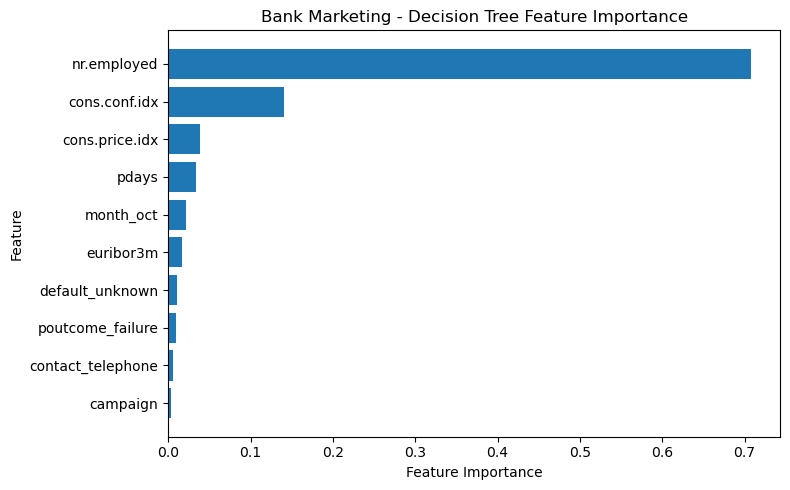

In [48]:
# Bank Marketing feature importance chart

bank_top_features = bank_dt_features.head(10).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(
    bank_top_features["Feature"],
    bank_top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Bank Marketing - Decision Tree Feature Importance")
plt.tight_layout()

# Save BEFORE displaying
plt.savefig(
    "bank_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

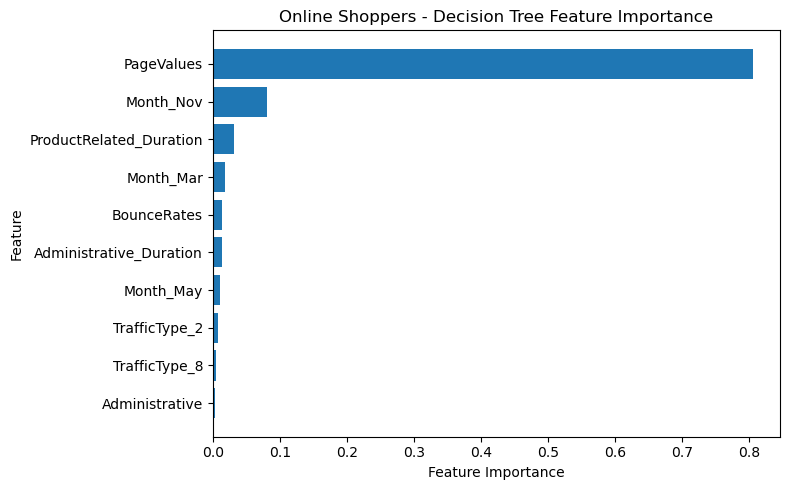

In [49]:
# Online Shoppers feature importance chart

shop_top_features = shop_dt_features.head(10).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(
    shop_top_features["Feature"],
    shop_top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Online Shoppers - Decision Tree Feature Importance")
plt.tight_layout()

# Save BEFORE displaying
plt.savefig(
    "shop_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

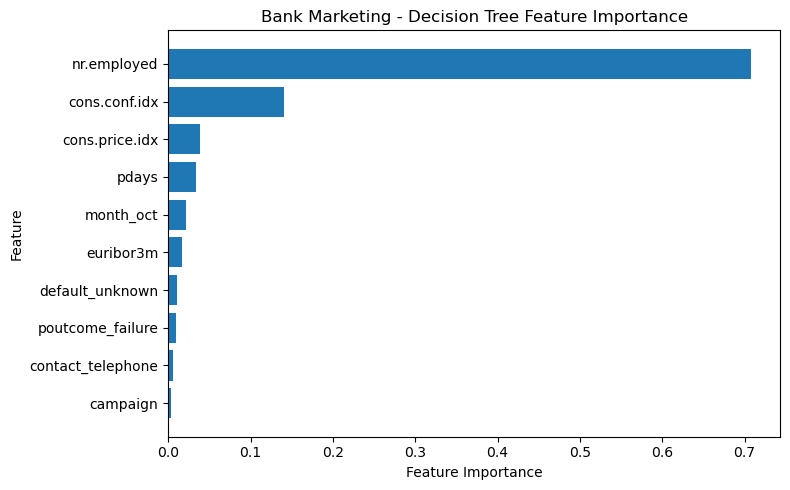

In [50]:
plt.figure(figsize=(8, 5))
plt.barh(bank_top_features["Feature"], bank_top_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Bank Marketing - Decision Tree Feature Importance")
plt.tight_layout()
plt.savefig("bank_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

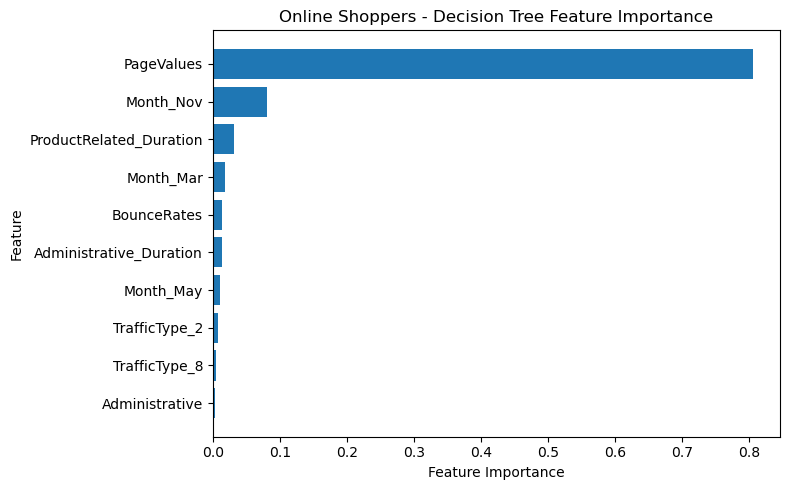

In [51]:
plt.figure(figsize=(8, 5))
plt.barh(shop_top_features["Feature"], shop_top_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Online Shoppers - Decision Tree Feature Importance")
plt.tight_layout()
plt.savefig("shop_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()